In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
# importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# sklearn for scaling, clustering, pca and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# setting plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print('libraries imported')

libraries imported


In [3]:
# on kaggle the dataset is already attached, just read it directly from the input folder
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')

print('shape of dataset:', df.shape)
df.head(10)

shape of dataset: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
5,Argentina,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300
6,Armenia,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220
7,Australia,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900
8,Austria,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900
9,Azerbaijan,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840


In [4]:
# checking basic info about the dataset
print('Shape:', df.shape)
print()
print('Column names:', df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)
print()

# checking for missing values
print('Missing values per column:')
print(df.isnull().sum())
print()

# checking if there are any duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Shape: (167, 10)

Column names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0


In [5]:
# looking at statistical summary of all numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


In [6]:
# making column names lowercase and removing any extra spaces
df.columns = [c.strip().lower() for c in df.columns]

# dropping duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)

# getting all numeric columns (everything except country name)
numeric_cols = [c for c in df.columns if c != 'country']

# converting all numeric columns to proper numeric type
# errors='coerce' will turn any bad values into NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# filling missing values with median of each column
# using median because it is less affected by outliers
missing_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
missing_after = df[numeric_cols].isnull().sum().sum()

print('missing values before:', missing_before)
print('missing values after:', missing_after)
print('final shape:', df.shape)
df.head(5)

missing values before: 0
missing values after: 0
final shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


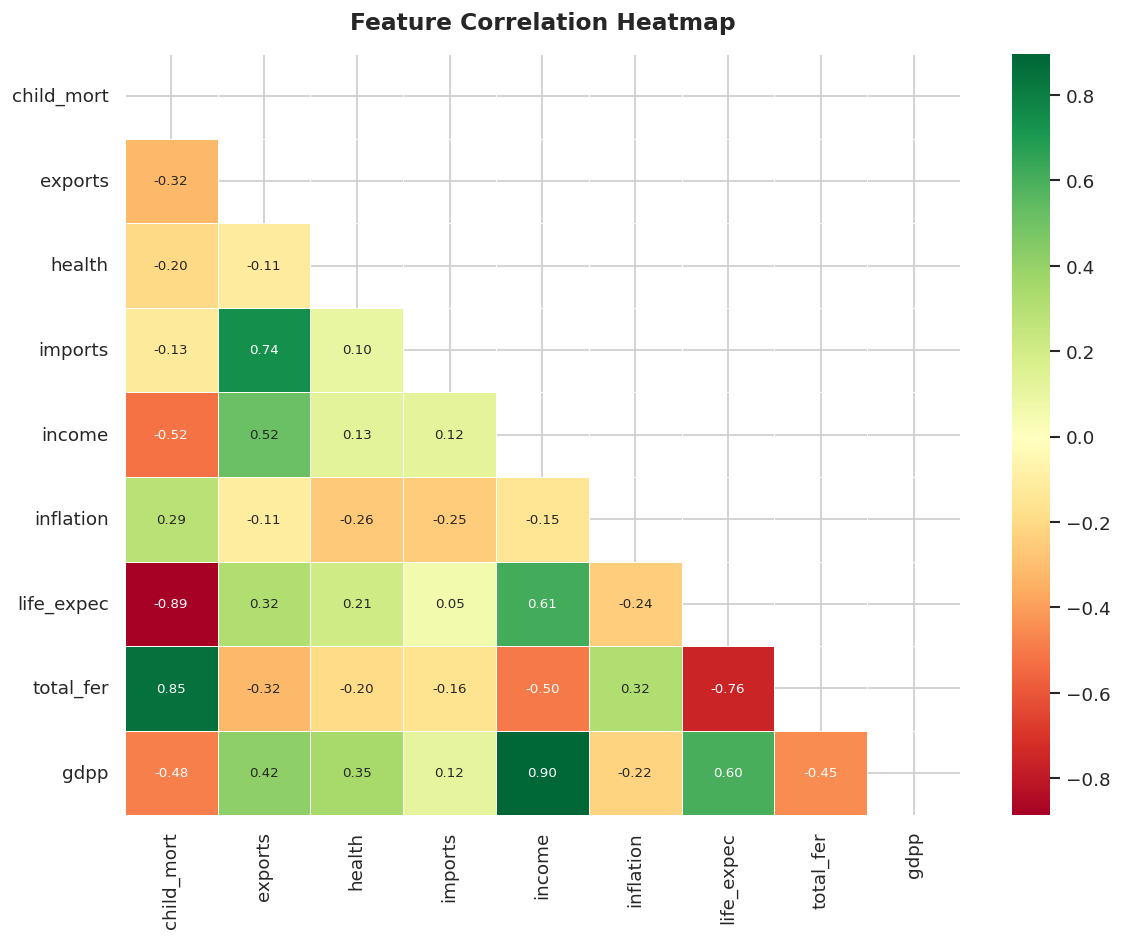

Top positive correlations:
income      gdpp         0.90
total_fer   child_mort   0.85
exports     imports      0.74
life_expec  income       0.61
gdpp        life_expec   0.60


In [7]:
# correlation heatmap to see which features are related to each other
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()

# masking upper triangle so we don't show duplicate values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# printing top correlated pairs
print('Top positive correlations:')
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(5).to_string())

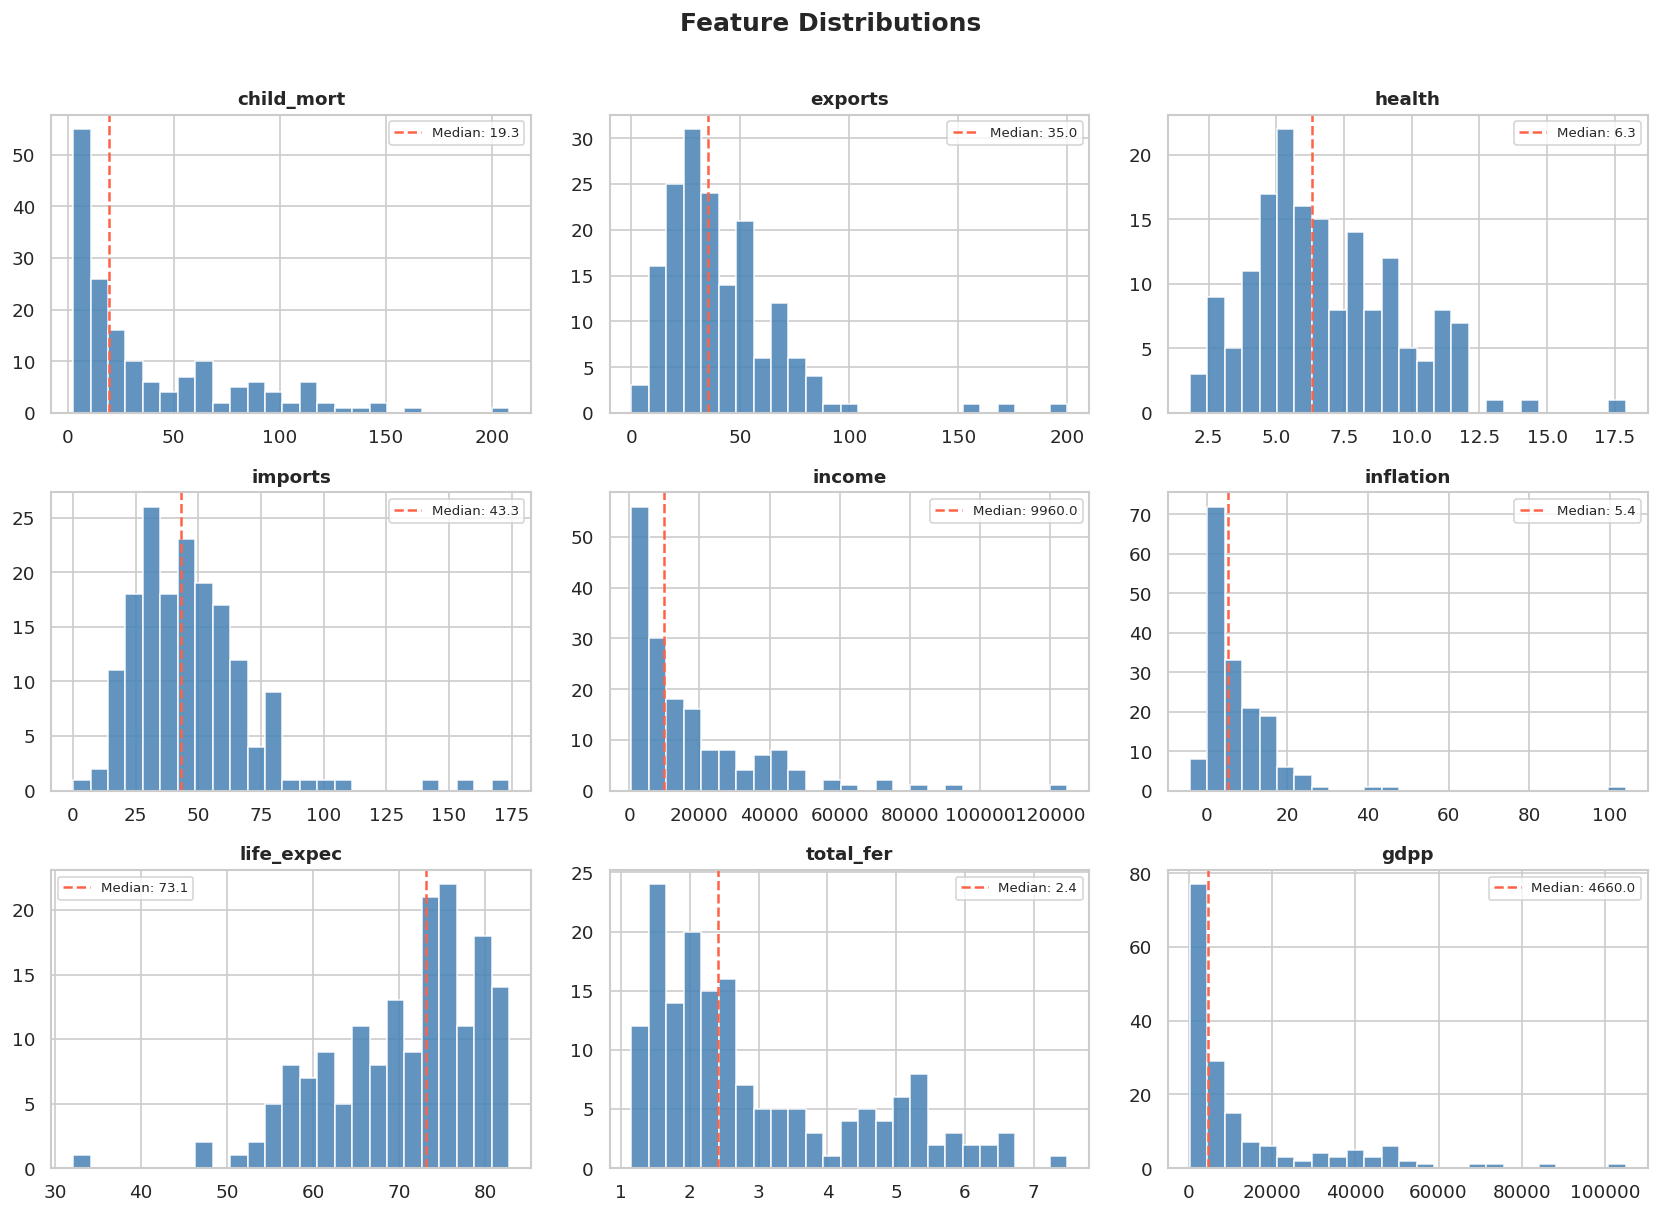

In [8]:
# plotting distribution of each feature to understand the spread
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # histogram for each column
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    # adding median line to see where most values are concentrated
    axes[i].axvline(df[col].median(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

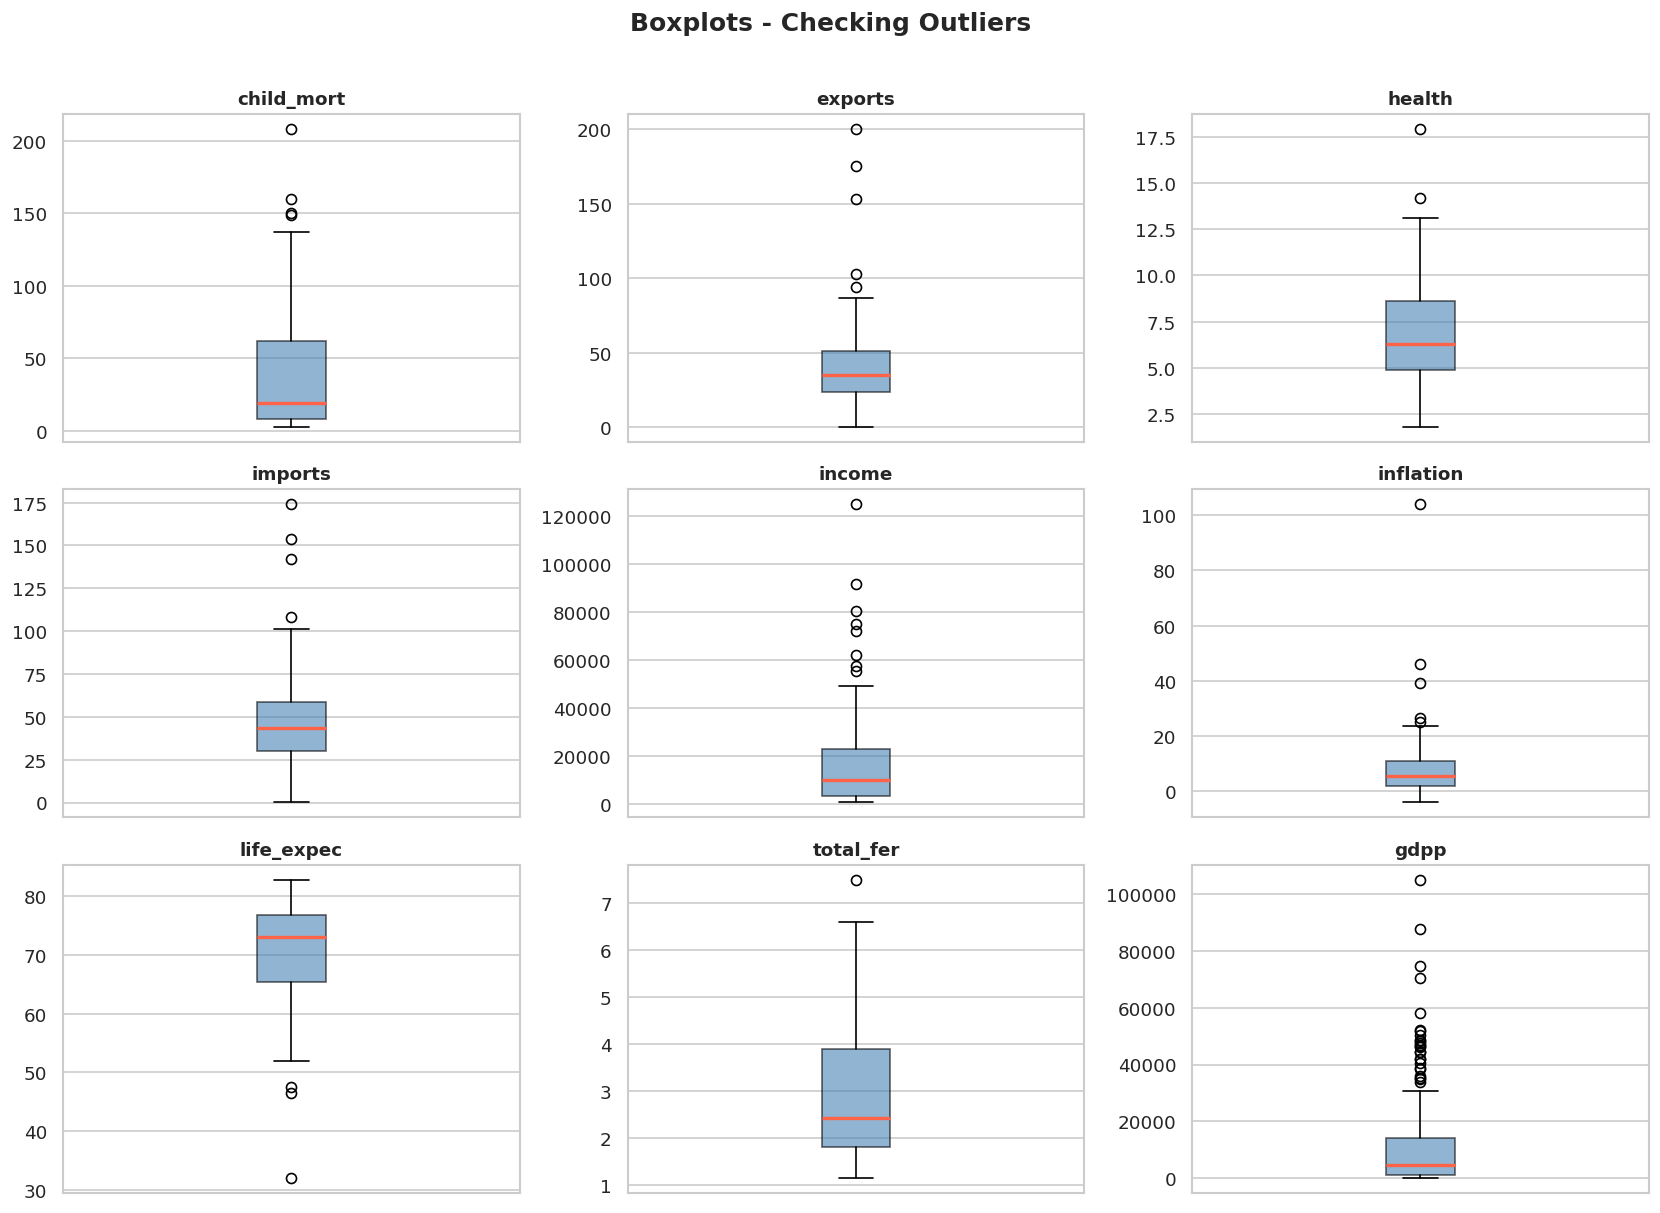

In [9]:
# boxplots to check for outliers in each feature
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xticks([])

plt.suptitle('Boxplots - Checking Outliers', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

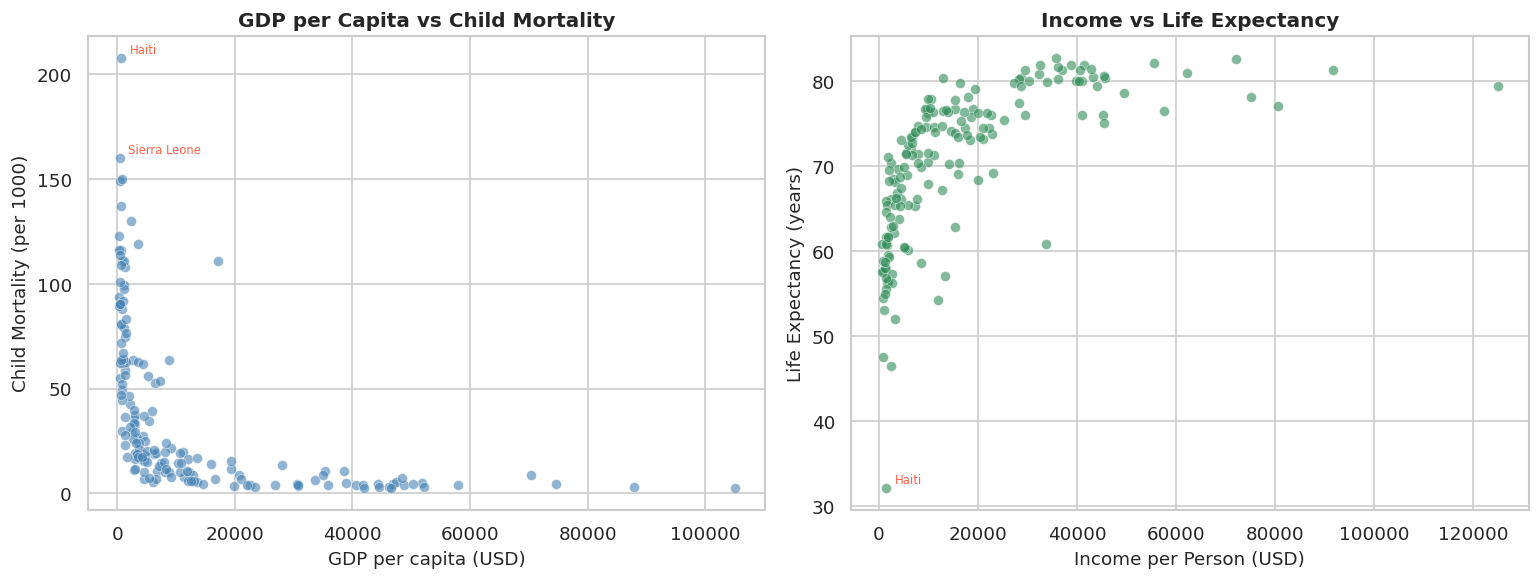

In [10]:
# scatter plots to see relationship between key features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# gdpp vs child_mort - expect higher gdp to have lower child mortality
axes[0].scatter(df['gdpp'], df['child_mort'], alpha=0.6, color='steelblue',
                edgecolors='white', linewidth=0.4)
axes[0].set_xlabel('GDP per capita (USD)', fontsize=11)
axes[0].set_ylabel('Child Mortality (per 1000)', fontsize=11)
axes[0].set_title('GDP per Capita vs Child Mortality', fontweight='bold')

# labeling countries with very high child mortality
for _, row in df[df['child_mort'] > 150].iterrows():
    axes[0].annotate(row['country'], (row['gdpp'], row['child_mort']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7, color='tomato')

# income vs life expectancy
axes[1].scatter(df['income'], df['life_expec'], alpha=0.6, color='seagreen',
                edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Income per Person (USD)', fontsize=11)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[1].set_title('Income vs Life Expectancy', fontweight='bold')

# labeling countries with very low life expectancy
for _, row in df[df['life_expec'] < 45].iterrows():
    axes[1].annotate(row['country'], (row['income'], row['life_expec']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7, color='tomato')

plt.tight_layout()
plt.show()

In [11]:
# applying standard scaling before clustering
# this is important because kmeans uses euclidean distance
# without scaling, features with large values like gdpp would dominate
features = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# verifying that scaling worked - mean should be near 0 and std near 1
scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
print('after scaling - mean and std of each feature:')
print(scaled_df.describe().loc[['mean', 'std']].round(3))

after scaling - mean and std of each feature:
      child_mort  exports  health  imports  income  inflation  life_expec  \
mean       -0.00     0.00    0.00     0.00   -0.00      -0.00        0.00   
std         1.00     1.00    1.00     1.00    1.00       1.00        1.00   

      total_fer  gdpp  
mean       0.00  0.00  
std        1.00  1.00  


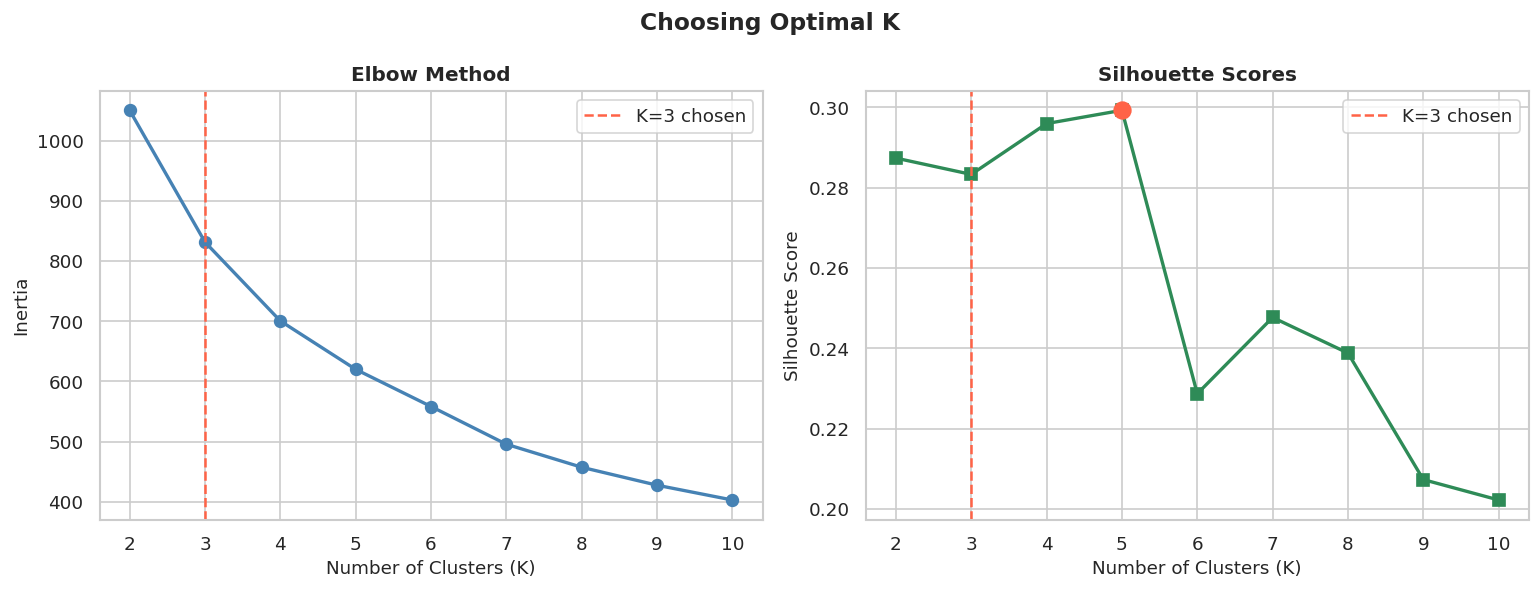

Best silhouette score: 0.2993 at K=5
  K=2  Inertia=1050.2  Silhouette=0.2874
  K=3  Inertia=831.4  Silhouette=0.2833
  K=4  Inertia=700.5  Silhouette=0.2960
  K=5  Inertia=620.2  Silhouette=0.2993
  K=6  Inertia=558.5  Silhouette=0.2287
  K=7  Inertia=495.8  Silhouette=0.2477
  K=8  Inertia=457.6  Silhouette=0.2388
  K=9  Inertia=427.8  Silhouette=0.2073
  K=10  Inertia=403.2  Silhouette=0.2022


In [12]:
# running kmeans for different values of k and storing inertia and silhouette score
# inertia = sum of squared distances from each point to its cluster center
# silhouette score = how well separated the clusters are, ranges from -1 to 1
inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# plotting both elbow curve and silhouette scores side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# elbow plot - look for the point where the curve bends
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=3, color='tomato', linestyle='--', linewidth=1.5, label='K=3 chosen')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(k_values))

# silhouette plot - higher is better
axes[1].plot(list(k_values), silhouettes, marker='s', color='seagreen', linewidth=2, markersize=7)
axes[1].axvline(x=3, color='tomato', linestyle='--', linewidth=1.5, label='K=3 chosen')
best_k_sil = k_values[silhouettes.index(max(silhouettes))]
axes[1].scatter([best_k_sil], [max(silhouettes)], color='tomato', zorder=5, s=100)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(k_values))

plt.suptitle('Choosing Optimal K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# printing the scores for each k
print(f'Best silhouette score: {max(silhouettes):.4f} at K={best_k_sil}')
for k, (i, s) in zip(k_values, zip(inertias, silhouettes)):
    print(f'  K={k}  Inertia={i:.1f}  Silhouette={s:.4f}')

In [13]:
# from the elbow plot the curve bends at k=3 so we use that
BEST_K = 3

# training the final kmeans model
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# checking silhouette score for the final model
sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
print('Silhouette Score:', round(sil_score, 4))

# how many countries in each cluster
print()
print('Countries per cluster:')
print(df['kmeans_cluster'].value_counts().sort_index())

# printing a few country names from each cluster to understand what each cluster looks like
print()
for c in range(BEST_K):
    countries = df[df['kmeans_cluster'] == c]['country'].values
    print(f'Cluster {c} ({len(countries)} countries): {list(countries[:6])} ...')

Silhouette Score: 0.2833

Countries per cluster:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

Cluster 0 (36 countries): ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada'] ...
Cluster 1 (47 countries): ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi'] ...
Cluster 2 (84 countries): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan'] ...


In [14]:
# trying dbscan as a second clustering approach
# dbscan does not need the number of clusters to be specified
# it also marks outlier points as -1 (noise)
# eps = radius of neighbourhood, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print('DBSCAN cluster distribution (-1 means outlier/noise):')
print(df['dbscan_cluster'].value_counts().sort_index())

# counting how many outliers were found
n_outliers = (df['dbscan_cluster'] == -1).sum()
n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f'\nNumber of clusters found: {n_clusters}')
print(f'Number of outliers: {n_outliers}')

# printing the outlier country names
if n_outliers > 0:
    outliers = df[df['dbscan_cluster'] == -1]['country'].values
    print(f'Outlier countries: {list(outliers)}')

DBSCAN cluster distribution (-1 means outlier/noise):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Number of clusters found: 1
Number of outliers: 30
Outlier countries: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


In [17]:
# using PCA to reduce 9 features down to 2 components so we can plot the clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# checking how much variance is explained by the 2 components
var_explained = pca.explained_variance_ratio_
print(f'Variance explained by PC1: {var_explained[0]:.1%}')
print(f'Variance explained by PC2: {var_explained[1]:.1%}')
print(f'Total variance captured: {sum(var_explained):.1%}')

# putting pca results in a dataframe for easy plotting
viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'KMeans': df['kmeans_cluster'].astype(str),
    'DBSCAN': df['dbscan_cluster'].astype(str),
    'Country': df['country']
})

Variance explained by PC1: 46.0%
Variance explained by PC2: 17.2%
Total variance captured: 63.1%


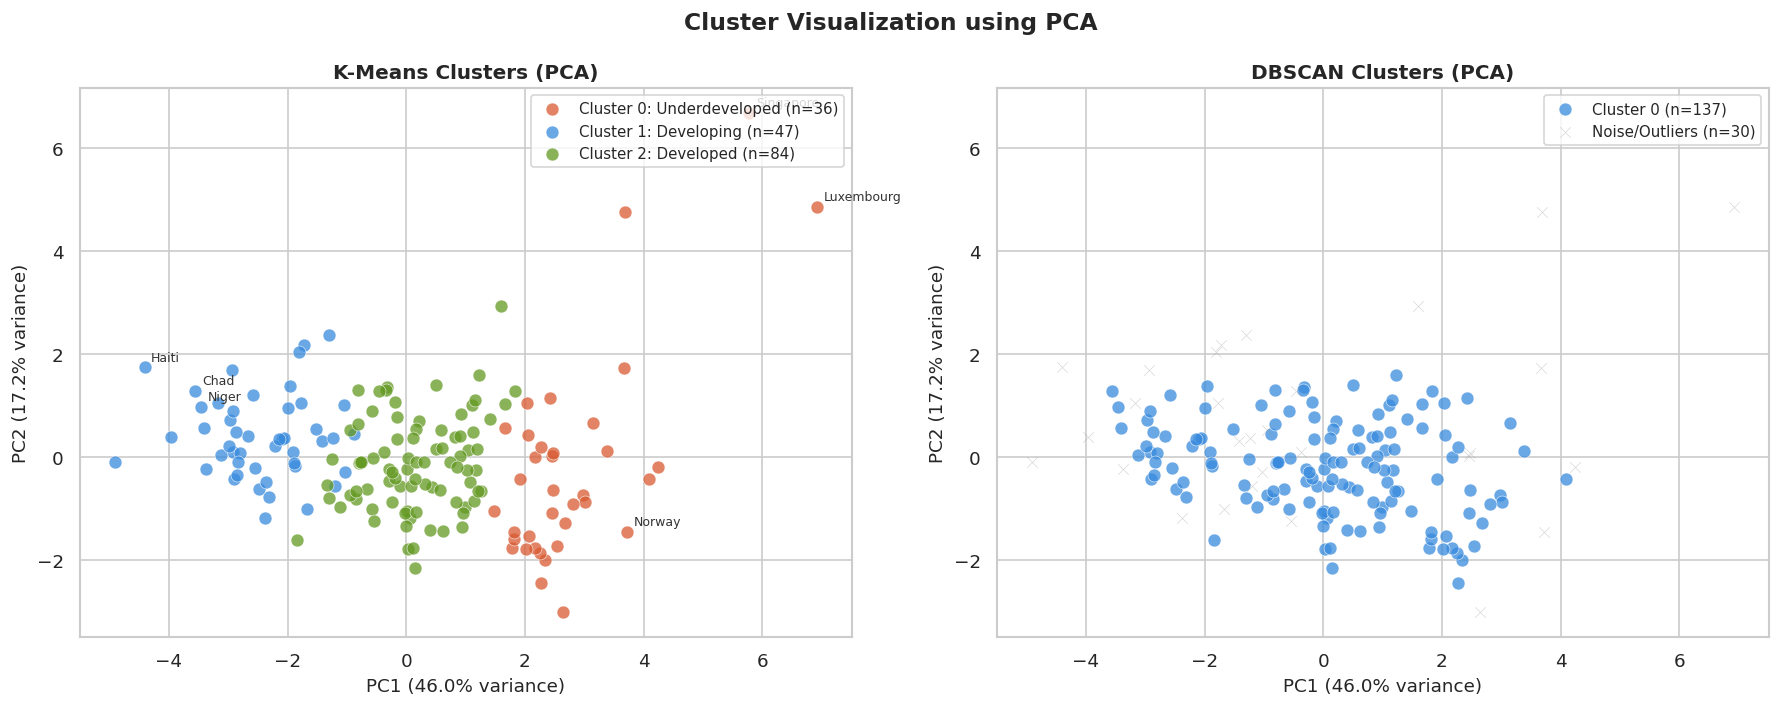

In [20]:
# plotting kmeans and dbscan clusters side by side using pca components
cluster_labels = {
    '0': 'Underdeveloped',
    '1': 'Developing',
    '2': 'Developed'
}
cluster_colors = {'0': '#D85A30', '1': '#378ADD', '2': '#639922'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# kmeans plot
for cluster_id, label in cluster_labels.items():
    mask = viz_df['KMeans'] == cluster_id
    subset = viz_df[mask]
    axes[0].scatter(
        subset['PC1'], subset['PC2'],
        label=f'Cluster {cluster_id}: {label} (n={mask.sum()})',
        color=cluster_colors[cluster_id],
        alpha=0.75, s=60, edgecolors='white', linewidth=0.4
    )

# adding labels for a few notable countries
highlight_countries = ['Haiti', 'Luxembourg', 'Singapore', 'Norway', 'Chad', 'Niger']
for _, row in viz_df[viz_df['Country'].isin(highlight_countries)].iterrows():
    axes[0].annotate(row['Country'], (row['PC1'], row['PC2']),
                     textcoords='offset points', xytext=(4, 4),
                     fontsize=7.5, color='#333')

axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontsize=11)
axes[0].set_title('K-Means Clusters (PCA)', fontweight='bold', fontsize=12)
axes[0].legend(fontsize=9, loc='upper right')

# dbscan plot - -1 means outlier points
dbscan_palette = {'0': '#378ADD', '1': '#F4C542', '2': '#E05C5C', '-1': '#999999'}
dbscan_label_map = {'-1': 'Noise/Outliers'}
for uid in viz_df['DBSCAN'].unique():
    mask = viz_df['DBSCAN'] == uid
    color = dbscan_palette.get(uid, '#aaaaaa')
    label = dbscan_label_map.get(uid, f'Cluster {uid}')
    # for outlier points (x marker) we skip edgecolors since x is an unfilled marker
    scatter_kwargs = dict(
        color=color,
        alpha=0.75 if uid != '-1' else 0.4,
        s=60 if uid != '-1' else 40,
        marker='o' if uid != '-1' else 'x',
        linewidth=0.4,
        label=f'{label} (n={mask.sum()})'
    )
    if uid != '-1':
        scatter_kwargs['edgecolors'] = 'white'
    axes[1].scatter(viz_df[mask]['PC1'], viz_df[mask]['PC2'], **scatter_kwargs)

axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontsize=11)
axes[1].set_title('DBSCAN Clusters (PCA)', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('Cluster Visualization using PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# looking at mean values of each feature per cluster to understand what each cluster represents
cluster_profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)

# renaming index for better readability
cluster_profile.index = [
    f'Cluster 0 - Underdeveloped ({(df["kmeans_cluster"]==0).sum()} countries)',
    f'Cluster 1 - Developing ({(df["kmeans_cluster"]==1).sum()} countries)',
    f'Cluster 2 - Developed ({(df["kmeans_cluster"]==2).sum()} countries)'
]

# using color gradient so differences between clusters are more visible
cluster_profile.T.style.background_gradient(cmap='RdYlGn', axis=1)

,Cluster 0 - Underdeveloped (36 countries),Cluster 1 - Developing (47 countries),Cluster 2 - Developed (84 countries)
child_mort,5.000000,92.960000,21.930000
exports,58.740000,29.150000,40.240000
health,8.810000,6.390000,6.200000
imports,51.490000,42.320000,47.470000
income,45672.220000,3942.400000,12305.600000
inflation,2.670000,12.020000,7.600000
life_expec,80.130000,59.190000,72.810000
total_fer,1.750000,5.010000,2.310000
gdpp,42494.440000,1922.380000,6486.450000


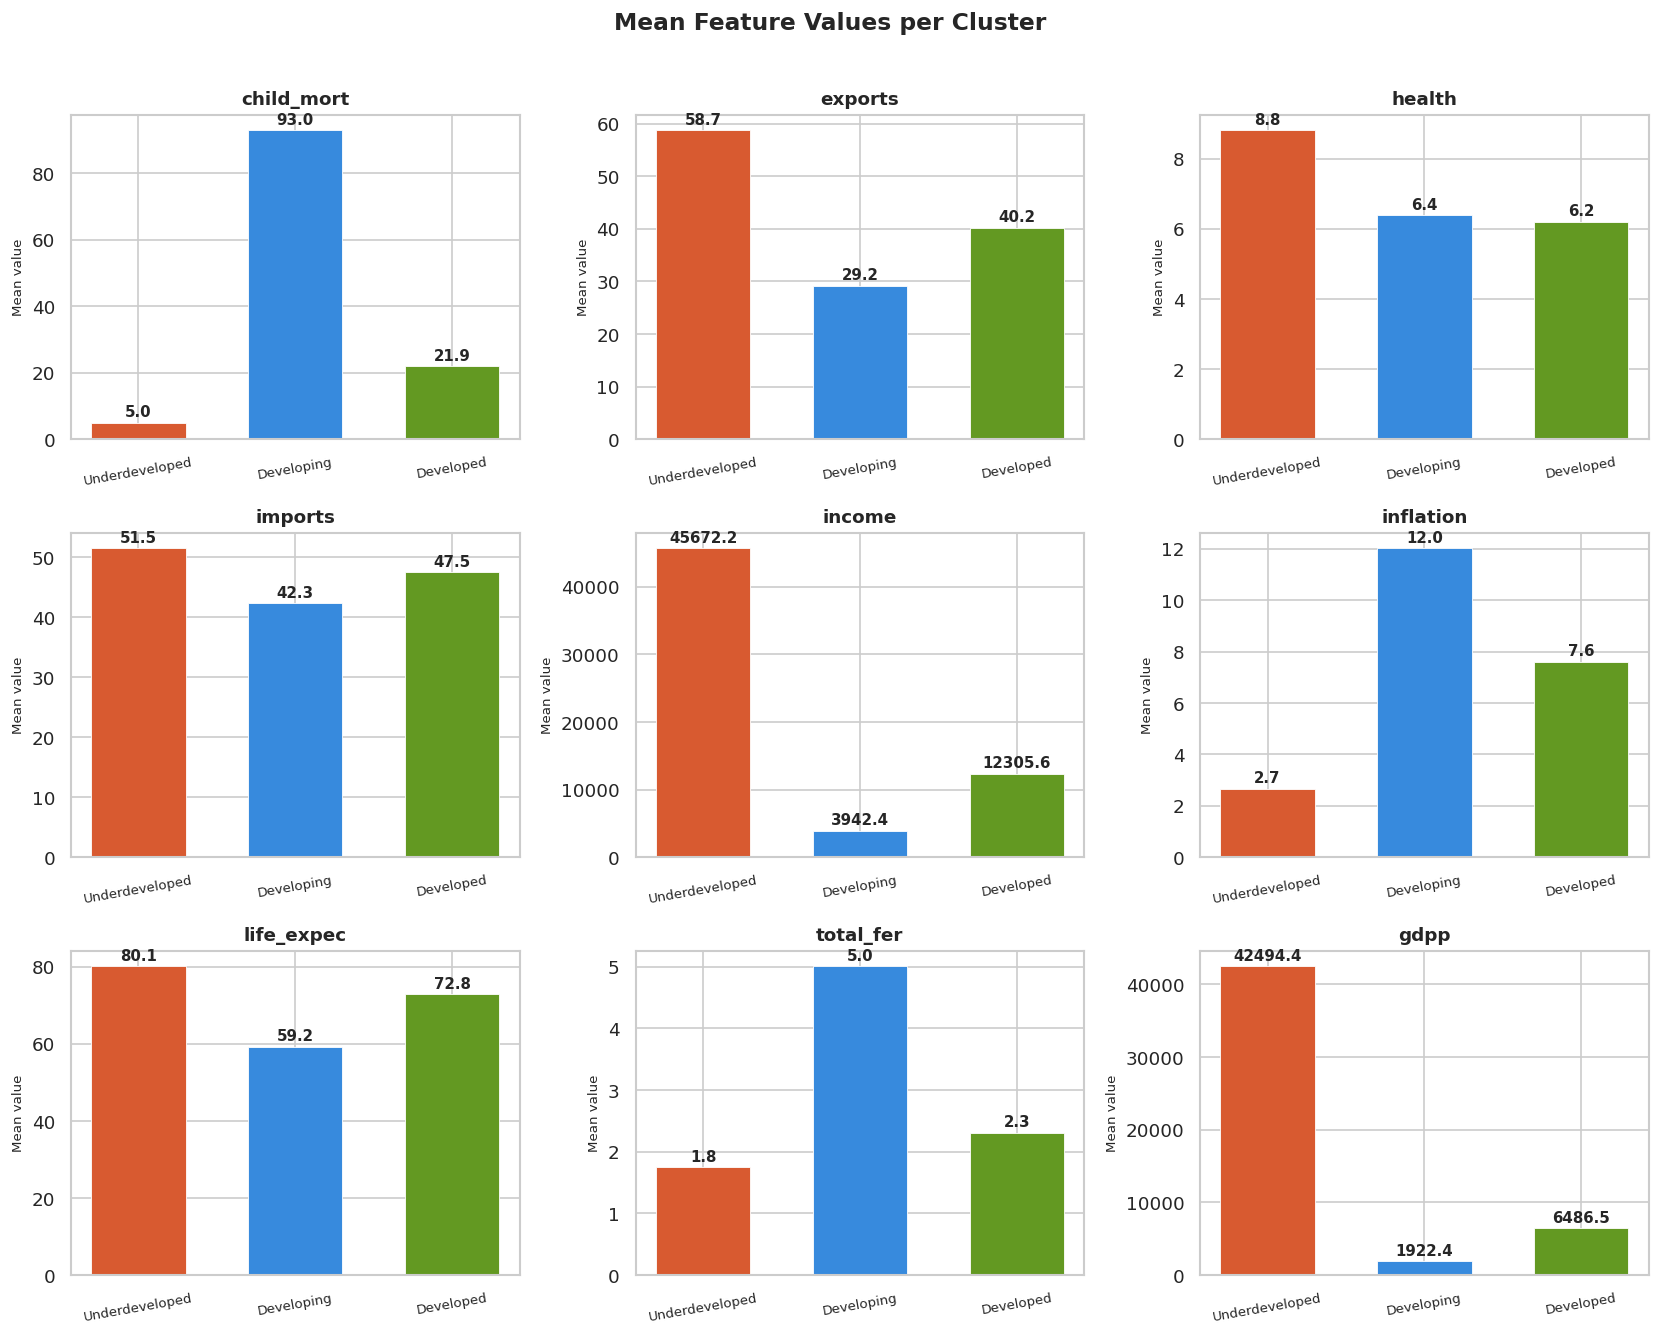

In [23]:
# bar plots comparing mean values of each feature across the 3 clusters
cluster_means = df.groupby('kmeans_cluster')[numeric_cols].mean()

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
colors = ['#D85A30', '#378ADD', '#639922']
cluster_names = ['Underdeveloped', 'Developing', 'Developed']

for i, col in enumerate(numeric_cols):
    values = cluster_means[col].values
    bars = axes[i].bar(cluster_names, values, color=colors, edgecolor='white', linewidth=0.5, width=0.6)
    # adding value labels on top of each bar
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(values)*0.01,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xticks(range(len(cluster_names)))
    axes[i].set_xticklabels(cluster_names, fontsize=8, rotation=10)
    axes[i].set_ylabel('Mean value', fontsize=8)

plt.suptitle('Mean Feature Values per Cluster', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# finding the countries that need the most aid (cluster 0)
# using a simple priority score based on high child mortality, low gdp and low life expectancy
aid_countries = df[df['kmeans_cluster'] == 0].copy()
aid_countries['priority_score'] = (
    aid_countries['child_mort'].rank(ascending=False) +
    aid_countries['gdpp'].rank(ascending=True) +
    (100 - aid_countries['life_expec']).rank(ascending=False)
) / 3

print('Top 10 countries that need aid (Cluster 0 - Underdeveloped):')
aid_top = aid_countries.nsmallest(10, 'priority_score')[['country', 'child_mort', 'gdpp', 'life_expec', 'income']]
print(aid_top.to_string(index=False))

# also looking at the top developed countries for comparison
print()
print('Top 10 Developed Countries (Cluster 2):')
dev_top = df[df['kmeans_cluster'] == 2].nlargest(10, 'gdpp')[['country', 'gdpp', 'income', 'life_expec', 'child_mort']]
print(dev_top.to_string(index=False))

Top 10 countries that need aid (Cluster 0 - Underdeveloped):
             country  child_mort  gdpp  life_expec  income
     Slovak Republic        7.00 16600       75.50   25200
             Bahrain        8.60 20700       76.00   41100
              Brunei       10.50 35300       77.10   80600
United Arab Emirates        8.60 35000       76.50   57600
              Kuwait       10.80 38500       78.20   75200
               Malta        6.80 21100       80.30   28300
      Czech Republic        3.40 19800       77.50   28300
       United States        7.30 48400       78.70   49400
            Portugal        3.90 22500       79.80   27200
         South Korea        4.10 22100       80.10   30400

Top 10 Developed Countries (Cluster 2):
     country  gdpp  income  life_expec  child_mort
     Bahamas 28000   22900       73.80       13.80
        Oman 19300   45300       76.10       11.70
Saudi Arabia 19300   45400       75.10       15.70
    Barbados 16000   15300       76.70       

In [25]:
# creating final output dataframe with cluster labels added
output_df = df[['country', 'kmeans_cluster', 'dbscan_cluster'] + numeric_cols].copy()

# figuring out correct label for each cluster based on avg gdpp
# kmeans assigns cluster numbers randomly each run so we can't hardcode 0=underdeveloped
# instead we rank clusters by average gdpp to assign the right label
cluster_gdpp = df.groupby('kmeans_cluster')['gdpp'].mean().sort_values()
gdpp_ranking = cluster_gdpp.index.tolist()  # sorted from lowest to highest gdpp

label_map = {
    gdpp_ranking[0]: 'Underdeveloped',
    gdpp_ranking[1]: 'Developing',
    gdpp_ranking[2]: 'Developed'
}

print('Cluster label mapping based on avg GDP per capita:')
for k, v in label_map.items():
    print(f'  Cluster {k} -> {v}  (avg gdpp: {cluster_gdpp[k]:.0f})')

output_df['kmeans_label'] = output_df['kmeans_cluster'].map(label_map)

# saving to csv
output_df.to_csv('country_clusters_results.csv', index=False)
print()
print('saved to country_clusters_results.csv')
print('shape:', output_df.shape)
output_df.head(10)

Cluster label mapping based on avg GDP per capita:
  Cluster 1 -> Underdeveloped  (avg gdpp: 1922)
  Cluster 2 -> Developing  (avg gdpp: 6486)
  Cluster 0 -> Developed  (avg gdpp: 42494)

saved to country_clusters_results.csv
shape: (167, 13)


,country,kmeans_cluster,dbscan_cluster,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_label
0,Afghanistan,1,0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,Underdeveloped
1,Albania,2,0,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,Developing
2,Algeria,2,0,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,Developing
3,Angola,1,-1,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,Underdeveloped
4,Antigua and Barbuda,2,0,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,Developing
5,Argentina,2,0,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300,Developing
6,Armenia,2,0,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220,Developing
7,Australia,0,0,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900,Developed
8,Austria,0,0,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900,Developed
9,Azerbaijan,2,0,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840,Developing


In [26]:
# on kaggle output files are saved to /kaggle/working/
# you can download them from the Output tab on the right panel after running
print('file saved to /kaggle/working/country_clusters_results.csv')
print('go to the Output section on the right side panel to download it')

file saved to /kaggle/working/country_clusters_results.csv
go to the Output section on the right side panel to download it
